# Automatidata | NYC Taxi Fare & Tipping Analysis

## Portfolio Case Study

This case study analyzes NYC yellow taxi trip data from three complementary perspectives:

1. **Payment method and fare amount:** Is there an observed difference in average fare between credit-card and cash trips?
2. **Fare estimation:** Can fare amount be estimated from information that can reasonably be available before a trip is completed?
3. **Generous tipping:** Can trip characteristics help identify customers whose tip is at least 20%?

The notebook combines exploratory analysis, statistical testing, leakage-aware feature engineering, cross-validated model selection, held-out test evaluation, error analysis, and model interpretation.

> **Important:** This is a portfolio analysis based on an educational dataset. It should not be presented as work performed for the NYC Taxi and Limousine Commission or as evidence about the full NYC taxi market.

## Business context and modeling objective

The Automatidata course scenario presents a consulting engagement with the New York City Taxi and Limousine Commission (TLC). The source material defines a fare-estimation regression task and a separate generous-tipping classification task.

**Portfolio framing:** this notebook is an independent portfolio case study based on the course scenario. It does not represent work performed for the NYC TLC, and the underlying dataset was created for educational purposes.

### Primary modeling question

> **How well can taxi fare be estimated before the ride is completed using information represented in the dataset?**

A second analysis examines whether payment method is associated with observed fare amount. The tipping model is treated as a separate classification exercise based on the original project framing.

## Analysis plan

The workflow is designed as a reproducible data-science case study:

- Inspect the raw data and document data-quality issues
- Clean only values that are clearly invalid
- Explore time, fare, distance, duration, payment, and location patterns
- Quantify the payment-group difference with Welch's t-test and a confidence interval
- Split the fare data into training, validation, and final test sets
- Build route-level features using the training partition
- Establish a linear regression baseline
- Compare Random Forest, XGBoost, and Gradient Boosting with cross-validation
- Select the fare model using **validation MAE only**
- Evaluate the selected fare model once on the untouched test set
- Diagnose where fare errors are concentrated
- Build and compare three generous-tipping classifiers using cross-validated F1
- Evaluate the selected classifier on a held-out test set
- Inspect model-based feature importance and document limitations
- Save the selected model artifacts for reproducibility

The test set is intentionally isolated from model selection. All reported conclusions below are based on the executed outputs stored in this notebook.

## Executive summary

### What was analyzed

The project combines a statistical comparison of payment groups with two predictive tasks: fare regression and generous-tip classification.

### Executed results

| Analysis | Result |
|---|---|
| Credit-card vs cash mean fare | Credit-card trips were higher by about **$1.22** on average |
| 95% CI for mean difference | **$0.87 to $1.56** |
| Welch test p-value | **6.8 × 10⁻¹²** |
| Fare model selected on validation | **Gradient Boosting** by MAE |
| Fare test MAE | **$3.55** |
| Fare test RMSE | **$16.41** |
| Fare test R² | **0.182** |
| Generous-tip classifier selected | **Random Forest** by cross-validated F1 |
| Tip test Precision | **0.456** |
| Tip test Recall | **0.731** |
| Tip test F1 | **0.562** |
| Tip test ROC AUC | **0.645** |

### Bottom line

The fare model captures useful structure, but its held-out test performance is materially weaker than its validation performance. The fare-error analysis shows substantially larger errors in the highest-fare segment.

The tipping classifier achieves higher recall than precision, meaning it identifies a relatively large share of generous tippers while also producing a substantial number of false positives.

Taken together, the results demonstrate a complete modeling workflow, but they do **not** support presenting either model as production-ready. The dataset is educational, and the fare model in particular needs stronger generalization evidence before operational use.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

from xgboost import XGBRegressor, XGBClassifier

import pickle

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
# Look for the dataset in the two locations commonly used for this project.
candidates = [
    Path("2017_Yellow_Taxi_Trip_Data.csv"),
    Path("C:\\Users\\king\\OneDrive\\سطح المكتب\\ADA\\Automatidata\\Automatidata final\\2017_Yellow_Taxi_Trip_Data.csv")
]

DATA_PATH = next((p for p in candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "2017_Yellow_Taxi_Trip_Data.csv was not found. "
        "Place it beside the notebook or inside a data/ folder."
    )

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df_raw.shape}")

Loaded: C:\Users\king\OneDrive\سطح المكتب\ADA\Automatidata\Automatidata final\2017_Yellow_Taxi_Trip_Data.csv
Shape: (22699, 18)


## 1. First look at the data

Before changing anything, I want to know what one row represents, which fields are available, and whether there are obvious quality problems.

In [3]:
df_raw.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,03/25/2017 8:55:43 AM,03/25/2017 9:09:47 AM,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04/11/2017 2:53:28 PM,04/11/2017 3:19:58 PM,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2017 7:26:56 AM,12/15/2017 7:34:08 AM,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05/07/2017 1:17:59 PM,05/07/2017 1:48:14 PM,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,04/15/2017 11:32:20 PM,04/15/2017 11:49:03 PM,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [4]:
print("Rows:", len(df_raw))
print("Columns:", df_raw.shape[1])
print("\nData types:")
display(df_raw.dtypes)

print("\nMissing values:")
display(df_raw.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df_raw.duplicated().sum())

Rows: 22699
Columns: 18

Data types:


Unnamed: 0                 int64
VendorID                   int64
tpep_pickup_datetime         str
tpep_dropoff_datetime        str
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag           str
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object


Missing values:


,missing
Unnamed: 0,0
VendorID,0
improvement_surcharge,0
tolls_amount,0
tip_amount,0
mta_tax,0
extra,0
fare_amount,0
payment_type,0
DOLocationID,0



Duplicate rows: 0


In [5]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,22699.0,NaN,NaN,NaN,56758486.171285,32744929.492148,12127.0,28520556.0,56731504.0,85374524.0,113486300.0
VendorID,22699.0,NaN,NaN,NaN,1.556236,0.496838,1.0,1.0,2.0,2.0,2.0
tpep_pickup_datetime,22699,22687,06/20/2017 6:57:39 PM,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tpep_dropoff_datetime,22699,22688,04/17/2017 7:39:36 AM,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
passenger_count,22699.0,NaN,NaN,NaN,1.642319,1.285231,0.0,1.0,1.0,2.0,6.0
trip_distance,22699.0,NaN,NaN,NaN,2.913313,3.653171,0.0,0.99,1.61,3.06,33.96
RatecodeID,22699.0,NaN,NaN,NaN,1.043394,0.708391,1.0,1.0,1.0,1.0,99.0
store_and_fwd_flag,22699,2,N,22600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PULocationID,22699.0,NaN,NaN,NaN,162.412353,66.633373,1.0,114.0,162.0,233.0,265.0
DOLocationID,22699.0,NaN,NaN,NaN,161.527997,70.139691,1.0,112.0,162.0,233.0,265.0


A few fields need special attention before modeling:

- pickup and dropoff timestamps need to be converted to datetime
- trip duration can be derived from those timestamps
- fare and duration contain values that need to be checked for plausibility
- location IDs are categorical identifiers rather than continuous measurements

I will keep the raw dataframe unchanged and work on a copy.

In [6]:
df = df_raw.copy()

df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"], errors="coerce"
)
df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"], errors="coerce"
)

df["duration"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print("Invalid pickup timestamps:", df["tpep_pickup_datetime"].isna().sum())
print("Invalid dropoff timestamps:", df["tpep_dropoff_datetime"].isna().sum())
print("Negative durations:", (df["duration"] < 0).sum())

Invalid pickup timestamps: 0
Invalid dropoff timestamps: 0
Negative durations: 1


## 2. Data quality and cleaning

Outliers are not automatically errors. A long taxi trip may be legitimate, while a negative fare or negative duration is a clear data-quality issue.

The cleaning step below corrects only those negative values. The regression target is **not clipped after the train/validation/test split**, so the final test target remains unchanged for evaluation.

For route-level features, the important leakage control happens later: route aggregates are learned from the training set only and then applied to validation/test rows.

In [7]:
quality_summary = pd.DataFrame({
    "zero_trip_distance": [(df["trip_distance"] == 0).sum()],
    "negative_fare": [(df["fare_amount"] < 0).sum()],
    "zero_fare": [(df["fare_amount"] == 0).sum()],
    "negative_duration": [(df["duration"] < 0).sum()],
    "zero_duration": [(df["duration"] == 0).sum()]
})

quality_summary

,zero_trip_distance,negative_fare,zero_fare,negative_duration,zero_duration
0,148,14,6,1,26


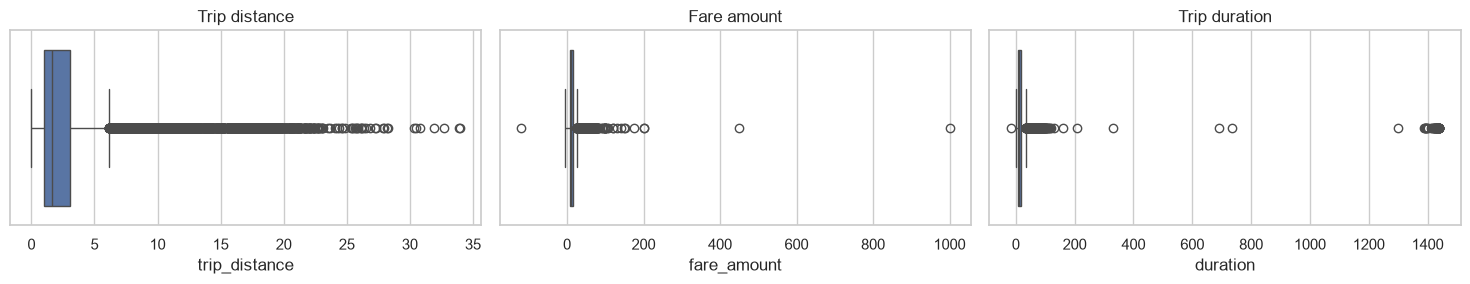

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

sns.boxplot(x=df["trip_distance"], ax=axes[0])
axes[0].set_title("Trip distance")

sns.boxplot(x=df["fare_amount"], ax=axes[1])
axes[1].set_title("Fare amount")

sns.boxplot(x=df["duration"], ax=axes[2])
axes[2].set_title("Trip duration")

plt.tight_layout()
plt.show()

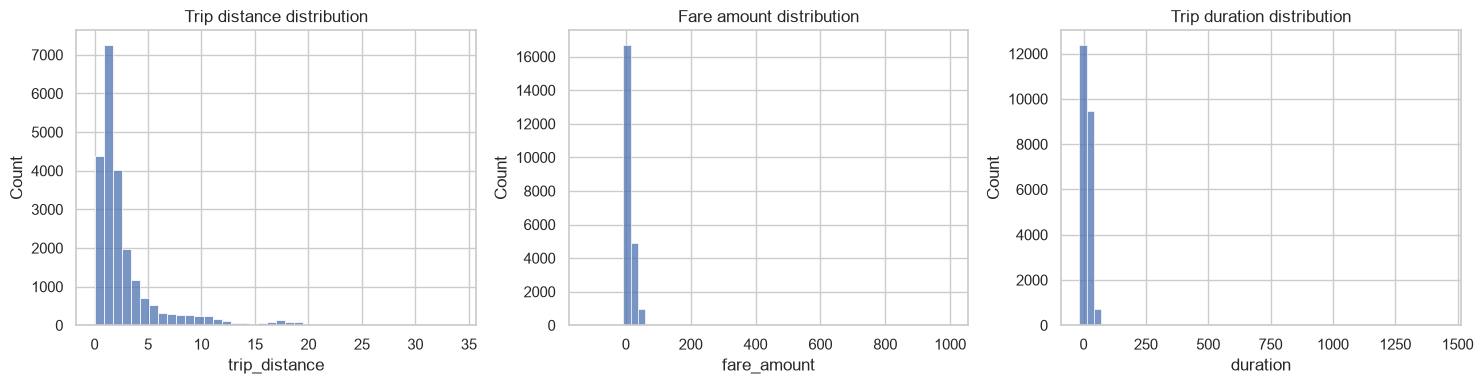

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["trip_distance"], bins=40, ax=axes[0])
axes[0].set_title("Trip distance distribution")

sns.histplot(df["fare_amount"], bins=50, ax=axes[1])
axes[1].set_title("Fare amount distribution")

sns.histplot(df["duration"], bins=50, ax=axes[2])
axes[2].set_title("Trip duration distribution")

plt.tight_layout()
plt.show()

### Basic cleaning rules

Negative fares and negative durations cannot represent valid completed trips, so they are set to zero for the modeling copy.

Zero-distance trips are kept. They are unusual, but they are not enough by themselves to justify deleting the records.

In [10]:
df["fare_amount"] = df["fare_amount"].clip(lower=0)
df["duration"] = df["duration"].clip(lower=0)

print("Negative fares after cleaning:", (df["fare_amount"] < 0).sum())
print("Negative durations after cleaning:", (df["duration"] < 0).sum())

Negative fares after cleaning: 0
Negative durations after cleaning: 0


## 3. Exploratory analysis

The first questions are simple:

- How are trips distributed across time?
- How do fare, distance, and duration move together?
- Does payment method show a difference in average fare?
- Are some pickup or drop-off locations responsible for a large share of trips?

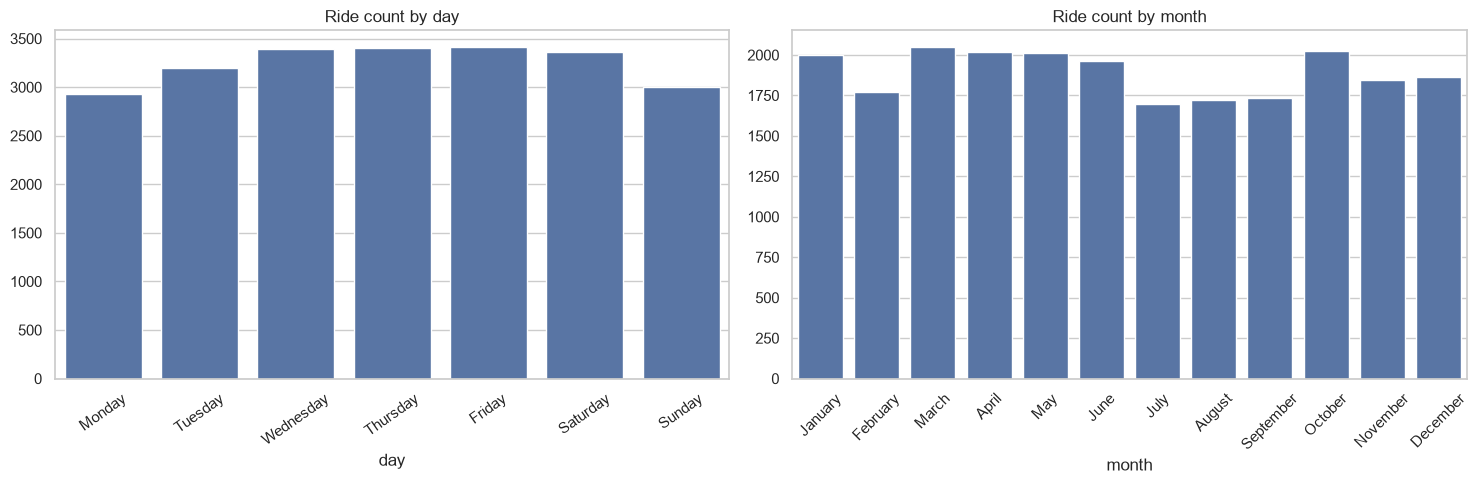

In [11]:
df["day"] = df["tpep_pickup_datetime"].dt.day_name()
df["month"] = df["tpep_pickup_datetime"].dt.month_name()
df["hour"] = df["tpep_pickup_datetime"].dt.hour

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

daily_rides = df["day"].value_counts().reindex(day_order)
monthly_rides = df["month"].value_counts().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=daily_rides.index, y=daily_rides.values, ax=axes[0])
axes[0].set_title("Ride count by day")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(x=monthly_rides.index, y=monthly_rides.values, ax=axes[1])
axes[1].set_title("Ride count by month")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

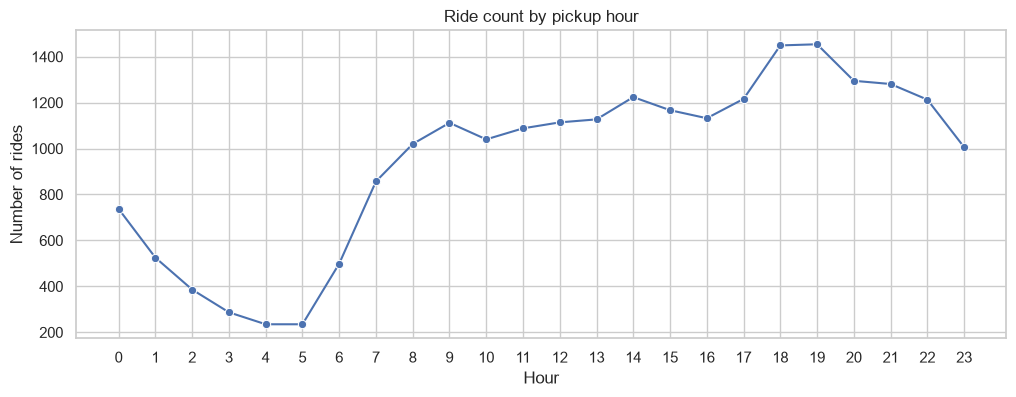

In [12]:
hourly_rides = df["hour"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
sns.lineplot(x=hourly_rides.index, y=hourly_rides.values, marker="o")
plt.title("Ride count by pickup hour")
plt.xlabel("Hour")
plt.ylabel("Number of rides")
plt.xticks(range(24))
plt.show()

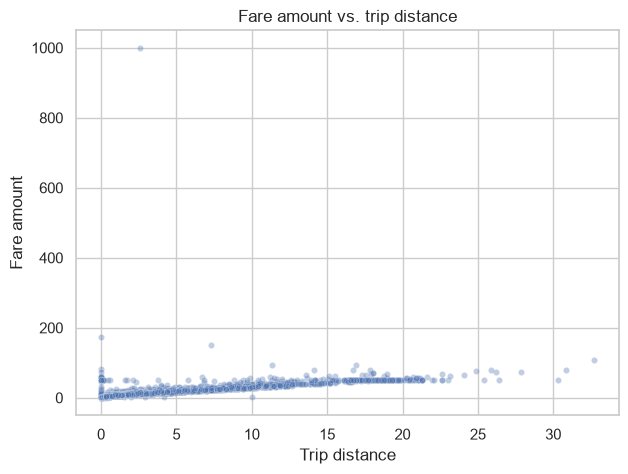

In [13]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df.sample(min(8000, len(df)), random_state=42),
    x="trip_distance",
    y="fare_amount",
    alpha=0.35,
    s=20
)
plt.title("Fare amount vs. trip distance")
plt.xlabel("Trip distance")
plt.ylabel("Fare amount")
plt.show()

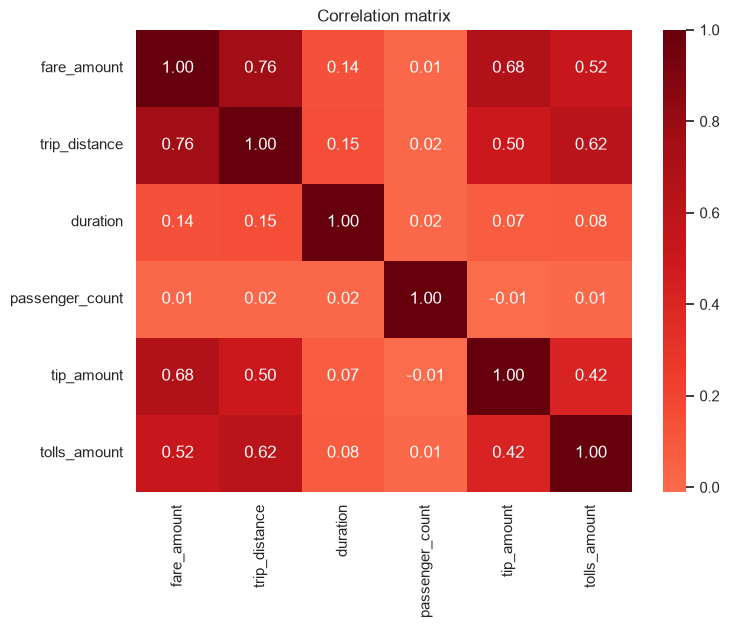

,fare_amount,trip_distance,duration,passenger_count,tip_amount,tolls_amount
fare_amount,1.000000,0.757989,0.137589,0.010455,0.680087,0.515076
trip_distance,0.757989,1.000000,0.153618,0.016496,0.502242,0.622857
duration,0.137589,0.153618,1.000000,0.016832,0.072609,0.084512
passenger_count,0.010455,0.016496,0.016832,1.000000,-0.009975,0.009532
tip_amount,0.680087,0.502242,0.072609,-0.009975,1.000000,0.422326
tolls_amount,0.515076,0.622857,0.084512,0.009532,0.422326,1.000000


In [14]:
corr_cols = [
    "fare_amount", "trip_distance", "duration",
    "passenger_count", "tip_amount", "tolls_amount"
]

corr = df[corr_cols].corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Reds", center=0)
plt.title("Correlation matrix")
plt.show()

corr

The correlation matrix is useful for screening relationships, but correlation alone does not tell us whether one variable causes another. It also does not tell us whether a feature will remain useful once the other predictors are included in a model.

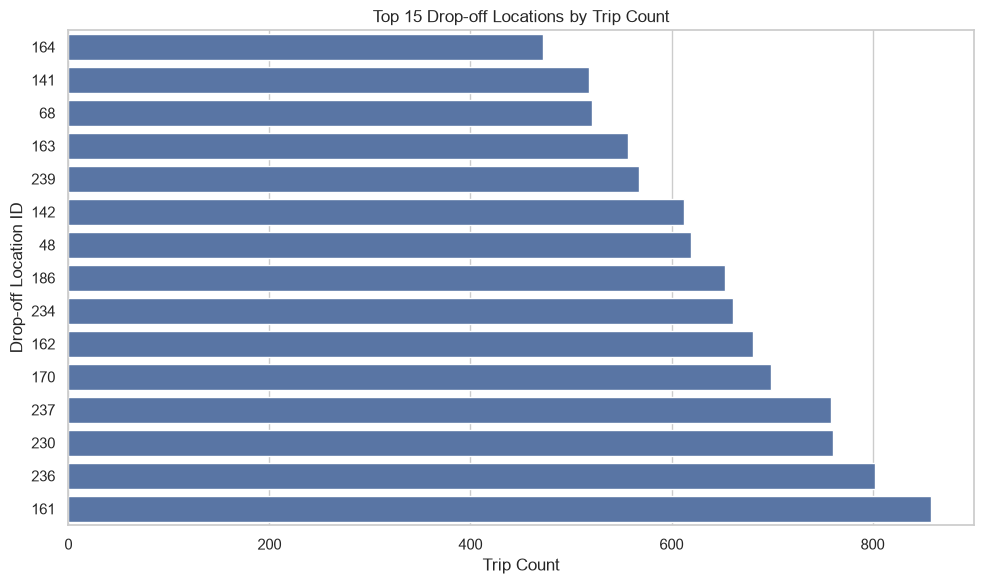

In [15]:
# Show the most frequently used drop-off locations for a readable comparison.
top_locations = (
    df["DOLocationID"]
    .value_counts()
    .head(15)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_locations.values,
    y=top_locations.index.astype(str)
)
plt.title("Top 15 Drop-off Locations by Trip Count")
plt.xlabel("Trip Count")
plt.ylabel("Drop-off Location ID")
plt.tight_layout()
plt.show()


## 4. Payment method and fare amount

The original project frames this as an A/B test. That conclusion needs one important condition:

For a causal interpretation, payment method would need to be assigned independently of the customer's expected fare. The observed taxi records do not establish that assignment.

So the analysis below tests whether the two payment groups have different average fares. Any causal wording depends on the stated random-assignment assumption.

In [16]:
payment_fares = (
    df[df["payment_type"].isin([1, 2])]
    .groupby("payment_type")["fare_amount"]
    .agg(["count", "mean", "median", "std"])
)

payment_fares.index = ["Credit card", "Cash"]
payment_fares

,count,mean,median,std
Credit card,15265,13.429748,9.5,13.848964
Cash,7267,12.213546,9.0,11.689940


In [17]:
credit_card = df.loc[df["payment_type"] == 1, "fare_amount"]
cash = df.loc[df["payment_type"] == 2, "fare_amount"]

ttest_result = stats.ttest_ind(
    credit_card,
    cash,
    equal_var=False
)

ttest_result

TtestResult(statistic=np.float64(6.866800855655361), pvalue=np.float64(6.797387473031004e-12), df=np.float64(16675.48547403633))

In [18]:
# 95% confidence interval for the difference in means
mean_diff = credit_card.mean() - cash.mean()

se = np.sqrt(
    credit_card.var(ddof=1) / len(credit_card)
    + cash.var(ddof=1) / len(cash)
)

df_welch = (
    (credit_card.var(ddof=1) / len(credit_card)
     + cash.var(ddof=1) / len(cash)) ** 2
    /
    (
        (credit_card.var(ddof=1) / len(credit_card)) ** 2 / (len(credit_card) - 1)
        +
        (cash.var(ddof=1) / len(cash)) ** 2 / (len(cash) - 1)
    )
)

critical_value = stats.t.ppf(0.975, df_welch)
ci_low = mean_diff - critical_value * se
ci_high = mean_diff + critical_value * se

payment_effect = pd.DataFrame({
    "mean_difference_credit_minus_cash": [mean_diff],
    "ci_95_low": [ci_low],
    "ci_95_high": [ci_high],
    "welch_df": [df_welch],
    "p_value": [ttest_result.pvalue]
})

payment_effect

,mean_difference_credit_minus_cash,ci_95_low,ci_95_high,welch_df,p_value
0,1.216202,0.869041,1.563362,16675.485474,6.797387e-12


### A useful sensitivity check

The fare distribution contains unusual values. I will repeat the comparison after excluding zero-fare records to see whether the direction of the result is sensitive to those observations.

This is not a replacement for the main test. It is a quick robustness check.

In [19]:
credit_positive = credit_card[credit_card > 0]
cash_positive = cash[cash > 0]

positive_test = stats.ttest_ind(
    credit_positive,
    cash_positive,
    equal_var=False
)

pd.DataFrame({
    "credit_mean": [credit_positive.mean()],
    "cash_mean": [cash_positive.mean()],
    "mean_difference": [credit_positive.mean() - cash_positive.mean()],
    "p_value": [positive_test.pvalue]
})

,credit_mean,cash_mean,mean_difference,p_value
0,13.432388,12.215227,1.217161,6.569926e-12


## 5. Regression problem

The primary predictive target is `fare_amount`.

A production-quality fare estimator should avoid variables that are created only after the trip. Therefore, the model does **not** use actual trip duration, actual trip distance, tip amount, or total amount as predictors.

Instead, the notebook creates route-level aggregate features from the training sample. These aggregates are a modeling proxy for information that could be available before a trip. In a production deployment, they should be generated from **historical trips available before the prediction timestamp**, not from future observations.

### Leakage control for route features

Route-level statistics are fitted from the training partition and then applied unchanged to validation and test rows. This prevents validation/test rows from contributing information to their own route aggregates.

The route features are treated as historical proxies rather than direct measurements available before every real-world trip. For production deployment, they should be generated from strictly historical data available before the prediction timestamp.

The current training implementation is suitable for this portfolio workflow, but a production-grade implementation should use out-of-fold or leave-one-out construction for training-row route aggregates to avoid each training trip contributing to its own aggregate.

In [20]:
model_df = df.copy()

model_df["pickup_dropoff"] = (
    model_df["PULocationID"].astype(str)
    + "_"
    + model_df["DOLocationID"].astype(str)
)

model_df["rush_hour"] = (
    (model_df["day"].isin(day_order[:5]))
    & (
        model_df["hour"].between(6, 9)
        | model_df["hour"].between(16, 19)
    )
).astype(int)

model_df = model_df[
    model_df["fare_amount"].notna()
    & model_df["pickup_dropoff"].notna()
].copy()

print(model_df.shape)

(22699, 24)


In [21]:
# Keep a separate test set for final evaluation.
train_df, test_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42
)

# Split the training portion again so model development has a validation set.
train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (14527, 24)
Validation: (3632, 24)
Test: (4540, 24)


In [22]:
def fit_route_statistics(train_data):
    route_stats = train_data.groupby("pickup_dropoff").agg(
        mean_distance=("trip_distance", "mean"),
        mean_duration=("duration", "mean"),
        route_count=("pickup_dropoff", "size")
    )
    return route_stats


route_stats = fit_route_statistics(train_df)

global_mean_distance = train_df["trip_distance"].mean()
global_mean_duration = train_df["duration"].mean()


def add_route_features(data, route_stats):
    out = data.copy()
    out = out.join(route_stats, on="pickup_dropoff")

    out["mean_distance"] = out["mean_distance"].fillna(global_mean_distance)
    out["mean_duration"] = out["mean_duration"].fillna(global_mean_duration)
    out["route_count"] = out["route_count"].fillna(0)

    return out


train_model = add_route_features(train_df, route_stats)
val_model = add_route_features(val_df, route_stats)
test_model = add_route_features(test_df, route_stats)

print("Route statistics learned from training rows:", len(route_stats))
print("Validation rows using fallback distance:", val_model["mean_distance"].eq(global_mean_distance).sum())
print("Test rows using fallback distance:", test_model["mean_distance"].eq(global_mean_distance).sum())

Route statistics learned from training rows: 3504
Validation rows using fallback distance: 350
Test rows using fallback distance: 452


### Regression target handling

The regression target is `fare_amount`.

No target clipping is applied after the train/validation/test split. This keeps the final test target intact and makes the held-out evaluation reflect the observed test distribution.

The earlier cleaning step removed only negative fares because they are invalid values, rather than treating legitimate high fares as errors.

In [23]:
# Keep the original target values for validation and final test evaluation.
# No target clipping is applied after the data split.
print("Regression target transformation: none after train/validation/test split")
print("Final test target remains untouched until final evaluation.")


Regression target transformation: none after train/validation/test split
Final test target remains untouched until final evaluation.


## 6. Regression features

The fare model uses a deliberately compact feature set:

- `passenger_count`
- training-set route mean distance
- training-set route mean duration
- `rush_hour`
- `VendorID`

Actual trip distance and actual trip duration are excluded because they describe the completed trip.

The route aggregates should be interpreted as **training-derived historical proxies**, not as proof that the same information would be available in exactly this form in a live booking system.

In [24]:
reg_features = [
    "passenger_count",
    "mean_distance",
    "mean_duration",
    "rush_hour",
    "VendorID"
]

X_train = train_model[reg_features].copy()
X_val = val_model[reg_features].copy()
X_test = test_model[reg_features].copy()

y_train = train_model["fare_amount"].copy()
y_val = val_model["fare_amount"].copy()
y_test = test_model["fare_amount"].copy()

X_train["VendorID"] = X_train["VendorID"].astype(str)
X_val["VendorID"] = X_val["VendorID"].astype(str)
X_test["VendorID"] = X_test["VendorID"].astype(str)

X_train = pd.get_dummies(X_train, columns=["VendorID"], drop_first=True)
X_val = pd.get_dummies(X_val, columns=["VendorID"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["VendorID"], drop_first=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Features used:")
print(X_train.columns.tolist())

Features used:
['passenger_count', 'mean_distance', 'mean_duration', 'rush_hour', 'VendorID_2']


## 7. Linear regression baseline

A linear model is useful here because it gives us a transparent baseline. If a more flexible model does not improve the results meaningfully, the simpler model may be easier to explain and maintain.

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

val_pred_lr = linear_model.predict(X_val_scaled)


def regression_metrics(y_true, pred, model_name):
    return pd.DataFrame({
        "model": [model_name],
        "R2": [r2_score(y_true, pred)],
        "MAE": [mean_absolute_error(y_true, pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_true, pred))]
    })


lr_val_results = regression_metrics(y_val, val_pred_lr, "Linear Regression")
lr_val_results


,model,R2,MAE,RMSE
0,Linear Regression,0.533466,3.625919,7.888475


MAE is the primary business-facing regression metric because it is expressed in dollars and represents the average absolute prediction error.

RMSE is also reported because it penalizes large errors more heavily. R² provides a relative measure of how much variance in fare is explained by the model.

For model selection, the notebook uses **validation MAE**. The final test set is reserved for the selected model only.

## 8. Random forest regression

The random forest is added as a second approach because fare relationships do not have to be perfectly linear. It can capture nonlinear patterns and interactions without requiring a large amount of manual transformation.

In [26]:
# Random Forest regression
rf_reg = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 12, 20],
    "min_samples_leaf": [1, 2, 4]
}

rf_reg_cv = GridSearchCV(
    estimator=rf_reg,
    param_grid=rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=4,
    n_jobs=-1,
    refit=True
)

rf_reg_cv.fit(X_train, y_train)

print("Random Forest combinations:", len(rf_reg_cv.cv_results_["params"]))
print("Random Forest best parameters:", rf_reg_cv.best_params_)
print("Random Forest best CV MAE:", -rf_reg_cv.best_score_)


# XGBoost regression
xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_reg_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.10],
    "min_child_weight": [1, 3]
}

xgb_reg_cv = GridSearchCV(
    estimator=xgb_reg,
    param_grid=xgb_reg_param_grid,
    scoring="neg_mean_absolute_error",
    cv=4,
    n_jobs=-1,
    refit=True
)

xgb_reg_cv.fit(X_train, y_train)

print("XGBoost combinations:", len(xgb_reg_cv.cv_results_["params"]))
print("XGBoost best parameters:", xgb_reg_cv.best_params_)
print("XGBoost best CV MAE:", -xgb_reg_cv.best_score_)


# Gradient Boosting regression
# This gives us a third tree-based architecture that is different from
# Random Forest and XGBoost while keeping the search compact.
gb_reg = GradientBoostingRegressor(random_state=42)

gb_reg_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [2, 3],
    "learning_rate": [0.05, 0.10],
    "min_samples_leaf": [1, 2]
}

gb_reg_cv = GridSearchCV(
    estimator=gb_reg,
    param_grid=gb_reg_param_grid,
    scoring="neg_mean_absolute_error",
    cv=4,
    n_jobs=-1,
    refit=True
)

gb_reg_cv.fit(X_train, y_train)

print("Gradient Boosting combinations:", len(gb_reg_cv.cv_results_["params"]))
print("Gradient Boosting best parameters:", gb_reg_cv.best_params_)
print("Gradient Boosting best CV MAE:", -gb_reg_cv.best_score_)


Random Forest combinations: 27
Random Forest best parameters: {'max_depth': 12, 'min_samples_leaf': 4, 'n_estimators': 200}
Random Forest best CV MAE: 2.2820934466233176
XGBoost combinations: 16
XGBoost best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 200}
XGBoost best CV MAE: 2.230776399049811
Gradient Boosting combinations: 16
Gradient Boosting best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 200}
Gradient Boosting best CV MAE: 2.216886926678514


In [27]:
val_pred_rf = rf_reg_cv.best_estimator_.predict(X_val)
val_pred_xgb = xgb_reg_cv.best_estimator_.predict(X_val)
val_pred_gb = gb_reg_cv.best_estimator_.predict(X_val)

regression_comparison = pd.concat([
    regression_metrics(y_val, val_pred_lr, "Linear Regression"),
    regression_metrics(y_val, val_pred_rf, "Random Forest"),
    regression_metrics(y_val, val_pred_xgb, "XGBoost"),
    regression_metrics(y_val, val_pred_gb, "Gradient Boosting")
], ignore_index=True)

regression_comparison.sort_values("MAE")


,model,R2,MAE,RMSE
3,Gradient Boosting,0.565618,3.485471,7.611799
1,Random Forest,0.602011,3.488185,7.285959
2,XGBoost,0.587507,3.495240,7.417531
0,Linear Regression,0.533466,3.625919,7.888475


The regression models are compared **only on the validation set**. The test set is not used for model selection.

The fare-model champion is selected using **validation MAE**, because MAE directly represents the average absolute prediction error in fare units. After selection, the champion is evaluated once on the untouched test set.

Other validation metrics such as RMSE and R² are retained as diagnostics rather than silently changing the selection rule.

In [28]:
val_comparison = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest", "XGBoost", "Gradient Boosting"],
    "MAE": [
        mean_absolute_error(y_val, val_pred_lr),
        mean_absolute_error(y_val, val_pred_rf),
        mean_absolute_error(y_val, val_pred_xgb),
        mean_absolute_error(y_val, val_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_val, val_pred_lr)),
        np.sqrt(mean_squared_error(y_val, val_pred_rf)),
        np.sqrt(mean_squared_error(y_val, val_pred_xgb)),
        np.sqrt(mean_squared_error(y_val, val_pred_gb))
    ],
    "R2": [
        r2_score(y_val, val_pred_lr),
        r2_score(y_val, val_pred_rf),
        r2_score(y_val, val_pred_xgb),
        r2_score(y_val, val_pred_gb)
    ]
})

val_comparison.sort_values("MAE")


,model,MAE,RMSE,R2
3,Gradient Boosting,3.485471,7.611799,0.565618
1,Random Forest,3.488185,7.285959,0.602011
2,XGBoost,3.495240,7.417531,0.587507
0,Linear Regression,3.625919,7.888475,0.533466


## 9. Regression diagnostics

The fare model has now been selected using validation MAE.

The untouched test set is used only for final evaluation and diagnostics. The analysis below checks:

- actual versus predicted fare
- residual behavior
- how absolute error changes across the fare distribution

These diagnostics are important because an average metric can hide concentrated failure on a specific segment of the target distribution.

In [29]:
# Select the regression champion using validation MAE only.
champion_reg_name = val_comparison.sort_values("MAE").iloc[0]["model"]

regression_models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_reg_cv.best_estimator_,
    "XGBoost": xgb_reg_cv.best_estimator_,
    "Gradient Boosting": gb_reg_cv.best_estimator_
}

champion_reg = regression_models[champion_reg_name]

# The test set is used here only after the model has been selected.
champion_test_pred = champion_reg.predict(X_test)

print("Selected regression model:", champion_reg_name)
print("Final test predictions generated after model selection.")


Selected regression model: Gradient Boosting
Final test predictions generated after model selection.


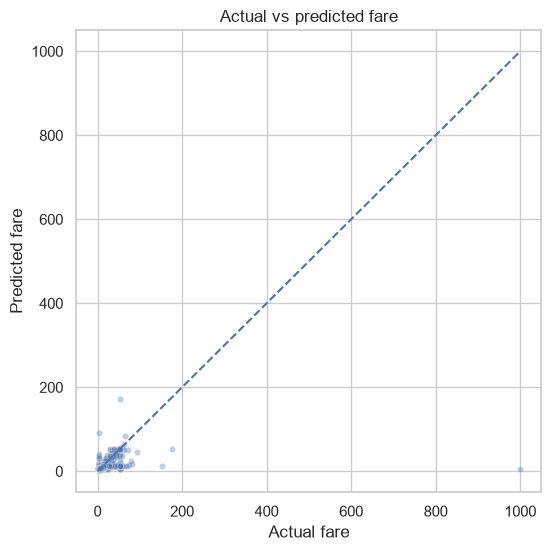

In [30]:
reg_results = pd.DataFrame({
    "actual": y_test.to_numpy(),
    "predicted": champion_test_pred
})

reg_results["residual"] = reg_results["actual"] - reg_results["predicted"]

plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=reg_results.sample(min(8000, len(reg_results)), random_state=42),
    x="actual",
    y="predicted",
    alpha=0.35,
    s=20
)

lims = [
    min(reg_results["actual"].min(), reg_results["predicted"].min()),
    max(reg_results["actual"].max(), reg_results["predicted"].max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual fare")
plt.ylabel("Predicted fare")
plt.title("Actual vs predicted fare")
plt.show()

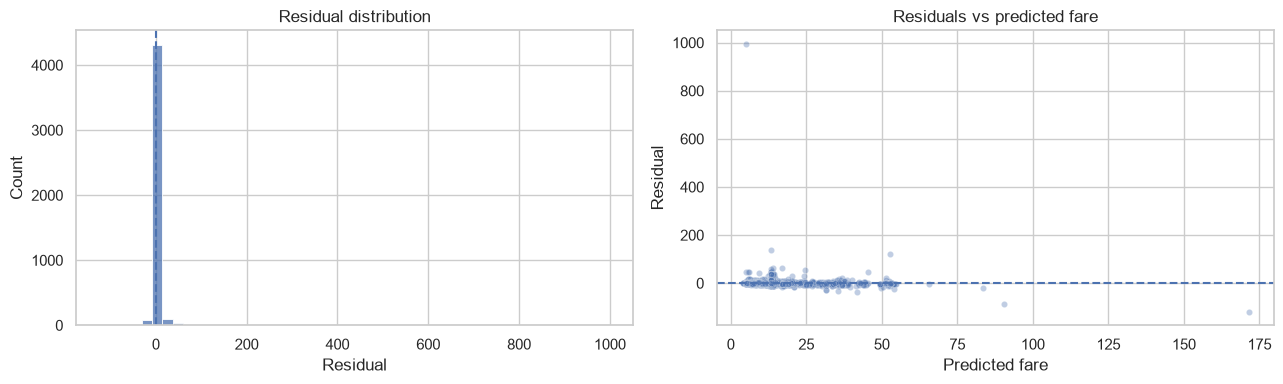

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(reg_results["residual"], bins=50, ax=axes[0])
axes[0].axvline(0, linestyle="--")
axes[0].set_title("Residual distribution")
axes[0].set_xlabel("Residual")

sns.scatterplot(
    data=reg_results.sample(min(8000, len(reg_results)), random_state=42),
    x="predicted",
    y="residual",
    alpha=0.35,
    s=20,
    ax=axes[1]
)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Residuals vs predicted fare")
axes[1].set_xlabel("Predicted fare")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

In [32]:
reg_results["absolute_error"] = reg_results["residual"].abs()

error_by_fare = pd.qcut(
    reg_results["actual"],
    q=5,
    duplicates="drop"
)

fare_error_summary = (
    reg_results.groupby(error_by_fare, observed=True)["absolute_error"]
    .agg(
        count="count",
        mean_absolute_error="mean",
        median_absolute_error="median"
    )
    .reset_index()
    .rename(columns={"actual": "fare_range"})
)

display(fare_error_summary)


,fare_range,count,mean_absolute_error,median_absolute_error
0,"(-0.001, 6.0]",1013,2.343483,1.582873
1,"(6.0, 8.0]",862,1.541394,1.127472
2,"(8.0, 10.5]",853,1.768279,1.488014
3,"(10.5, 16.0]",907,2.333029,1.908767
4,"(16.0, 999.99]",905,9.733917,5.139021


The error-by-fare table is a diagnostic for **where the model struggles**, not a second model-selection criterion.

The final interpretation should use the actual values in the table. In particular, large errors in higher-fare trips would indicate that the model is less reliable for that segment, even if average MAE remains moderate.

## 10. Regression feature contribution

For the linear baseline, standardized coefficients show the relative direction and magnitude of the fitted linear relationships.

For the tree-based champion, feature importance indicates how much the fitted model relied on each input when making predictions.

These are **model interpretation measures, not causal effects**. A high importance score does not establish that changing the feature would cause fare to change.

In [33]:
lr_coefficients = pd.Series(
    linear_model.coef_,
    index=X_train.columns
).sort_values(key=np.abs, ascending=False)

lr_coefficients.to_frame("standardized_coefficient")

,standardized_coefficient
mean_distance,9.895552
mean_duration,0.272336
rush_hour,0.243569
passenger_count,0.020379
VendorID_2,-0.008149


,importance
mean_distance,0.856170
mean_duration,0.112564
passenger_count,0.029874
VendorID_2,0.000852
rush_hour,0.000541


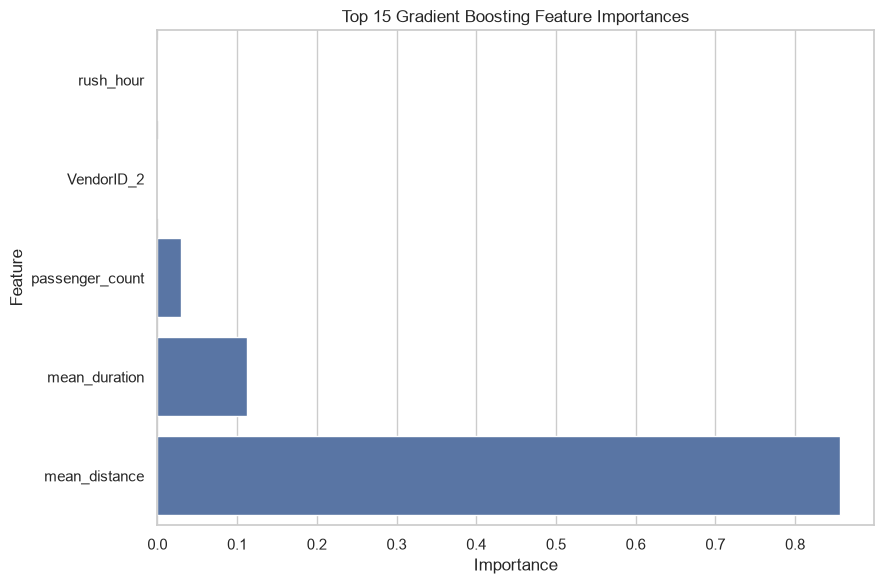

In [34]:
if hasattr(champion_reg, "feature_importances_"):
    importance = pd.Series(
        champion_reg.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    display(importance.to_frame("importance"))

    top_importance = importance.head(15).sort_values(ascending=True)

    plt.figure(figsize=(9, 6))
    sns.barplot(
        x=top_importance.values,
        y=top_importance.index
    )
    plt.title(f"Top 15 {champion_reg_name} Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


## 11. Additional modeling question: generous tipping

The original Automatidata project also examines whether a rider can be classified as a **generous tipper**, defined as tipping at least 20%. The course executive summary describes this as a separate machine-learning question and notes that the available data provide limited predictive strength.

This notebook treats tipping as a binary classification problem and evaluates Random Forest, XGBoost, and Gradient Boosting using cross-validated F1.

The test set is held out until after model selection.

In [35]:
tip_df = df.copy()

tip_df["fare_before_tip"] = tip_df["total_amount"] - tip_df["tip_amount"]

tip_df = tip_df[
    (tip_df["payment_type"] == 1)
    & (tip_df["fare_before_tip"] > 0)
    & tip_df["tip_amount"].notna()
].copy()

tip_df["tip_percent"] = (
    tip_df["tip_amount"] / tip_df["fare_before_tip"]
)

tip_df["generous"] = (tip_df["tip_percent"] >= 0.20).astype(int)

print("Credit-card trips:", len(tip_df))
print("\nTarget distribution:")
print(tip_df["generous"].value_counts(normalize=True).rename("proportion"))


Credit-card trips: 15262

Target distribution:
generous
0    0.651356
1    0.348644
Name: proportion, dtype: float64


The tipping predictors exclude variables that directly reveal the tip outcome or final trip totals, following the original project framing.

Excluded from the predictor matrix:

- `tip_amount`
- `tip_percent`
- `total_amount`
- `fare_amount`
- `trip_distance`
- `tolls_amount`

The retained variables are treated as candidate signals available in the dataset. A production implementation would require a field-by-field check of prediction-time availability.

**Important modeling note:** the route and trip-derived variables used in this educational case study should not automatically be interpreted as deployable real-time inputs. In a production pre-trip system, every feature must be constructed from information known before the prediction timestamp.

In [36]:
tip_df["day"] = tip_df["tpep_pickup_datetime"].dt.day_name()
tip_df["hour"] = tip_df["tpep_pickup_datetime"].dt.hour

tip_df["rush_hour"] = (
    tip_df["day"].isin(day_order[:5])
    & (
        tip_df["hour"].between(6, 9)
        | tip_df["hour"].between(16, 19)
    )
).astype(int)

# Use the retained variables from the original project framing.
# Prediction-time availability should be verified separately for deployment.
tip_features = [
    "passenger_count",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "extra",
    "mta_tax",
    "improvement_surcharge",
    "rush_hour",
    "VendorID"
]

X_tip = tip_df[tip_features].copy()
y_tip = tip_df["generous"].copy()

categorical_tip = ["RatecodeID", "PULocationID", "DOLocationID", "VendorID"]
X_tip[categorical_tip] = X_tip[categorical_tip].astype(str)
X_tip = pd.get_dummies(X_tip, columns=categorical_tip, drop_first=True)

X_tip_train, X_tip_test, y_tip_train, y_tip_test = train_test_split(
    X_tip,
    y_tip,
    test_size=0.20,
    random_state=42,
    stratify=y_tip
)

print("Training shape:", X_tip_train.shape)
print("Test shape:", X_tip_test.shape)
print("Number of model features:", X_tip_train.shape[1])


Training shape: (12209, 326)
Test shape: (3053, 326)
Number of model features: 326


In [37]:
# Generous tipping classification models
# All models are selected using cross-validation on the training set.
# The test set is evaluated only after the champion is selected.

tip_models = {
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
        eval_metric="logloss",
        scale_pos_weight=(y_tip_train == 0).sum() / (y_tip_train == 1).sum()
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

tip_grids = {
    "Random Forest": {
        "n_estimators": [200, 400, 600],
        "max_depth": [None, 12, 20],
        "min_samples_leaf": [1, 2, 4]
    },
    "XGBoost": {
        "n_estimators": [200, 400],
        "max_depth": [3, 6],
        "learning_rate": [0.05, 0.10],
        "min_child_weight": [1, 3]
    },
    "Gradient Boosting": {
        "n_estimators": [200, 400],
        "max_depth": [2, 3],
        "learning_rate": [0.05, 0.10],
        "min_samples_leaf": [1, 2]
    }
}

tip_searches = {}
tip_cv_summary = []

for name, model in tip_models.items():
    search = GridSearchCV(
        estimator=model,
        param_grid=tip_grids[name],
        scoring="f1",
        cv=4,
        n_jobs=-1,
        refit=True
    )
    search.fit(X_tip_train, y_tip_train)
    tip_searches[name] = search
    tip_cv_summary.append({
        "model": name,
        "combinations": len(search.cv_results_["params"]),
        "best_cv_f1": search.best_score_,
        "best_params": search.best_params_
    })

tip_cv_summary = pd.DataFrame(tip_cv_summary).sort_values(
    "best_cv_f1", ascending=False
).reset_index(drop=True)

display(tip_cv_summary)

tip_champion_name = tip_cv_summary.iloc[0]["model"]
tip_cv = tip_searches[tip_champion_name]
tip_champion_model = tip_cv.best_estimator_

tip_pred = tip_champion_model.predict(X_tip_test)
tip_prob = tip_champion_model.predict_proba(X_tip_test)[:, 1]

tip_results = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"],
    "value": [
        accuracy_score(y_tip_test, tip_pred),
        precision_score(y_tip_test, tip_pred, zero_division=0),
        recall_score(y_tip_test, tip_pred, zero_division=0),
        f1_score(y_tip_test, tip_pred, zero_division=0),
        roc_auc_score(y_tip_test, tip_prob)
    ]
})

print("Selected tipping model:", tip_champion_name)
print("Final tipping test evaluation completed after model selection.")
tip_results


,model,combinations,best_cv_f1,best_params
0,Random Forest,27,0.552936,"{'max_depth': 12, 'min_samples_leaf': 4, 'n_es..."
1,XGBoost,16,0.551839,"{'learning_rate': 0.05, 'max_depth': 3, 'min_c..."
2,Gradient Boosting,16,0.207695,"{'learning_rate': 0.1, 'max_depth': 3, 'min_sa..."


Selected tipping model: Random Forest
Final tipping test evaluation completed after model selection.


,metric,value
0,Accuracy,0.602686
1,Precision,0.456305
2,Recall,0.731203
3,F1,0.561936
4,ROC AUC,0.645463


,Predicted 0,Predicted 1
Actual 0,1062,927
Actual 1,286,778


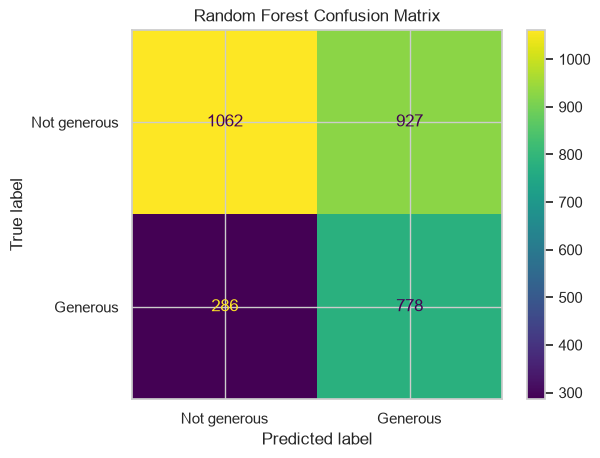

In [38]:
# Test-set confusion matrix for the selected tipping classifier
cm = confusion_matrix(y_tip_test, tip_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(cm_df)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not generous", "Generous"]
)
disp.plot()
plt.title(f"{tip_champion_name} Confusion Matrix")
plt.show()


## 11.1 Generous tipping model diagnostics

The confusion matrix makes the precision/recall trade-off visible on the held-out test set.

The feature-importance table and chart show which inputs the fitted classifier relied on most. These are **model-based importance measures**, not causal effects. A high importance value does not establish that changing that variable would change tipping behavior.

,importance
VendorID_2,0.431751
passenger_count,0.094381
extra,0.017367
PULocationID_148,0.013697
PULocationID_75,0.013485
...,...
PULocationID_133,0.000000
PULocationID_131,0.000000
PULocationID_130,0.000000
DOLocationID_173,0.000000


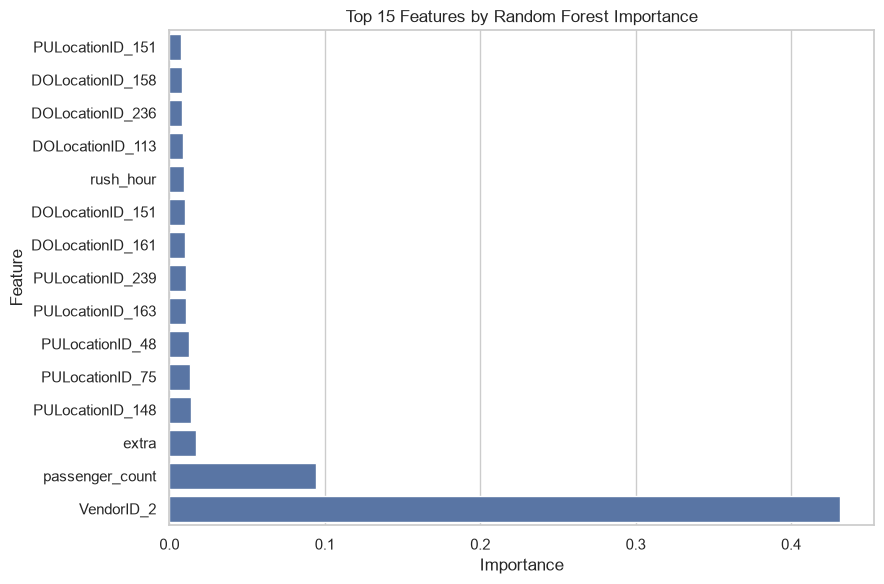

In [39]:
tip_importance = pd.Series(
    tip_champion_model.feature_importances_,
    index=X_tip_train.columns
).sort_values(ascending=False)

# Keep the full table available for analysis, but visualize only the
# most important features so the chart remains readable.
display(tip_importance.to_frame("importance"))

top_tip_importance = tip_importance.head(15).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
sns.barplot(
    x=top_tip_importance.values,
    y=top_tip_importance.index
)
plt.title(f"Top 15 Features by {tip_champion_name} Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 12. Final model summary

The cells below collect the final held-out test results after model selection.

No metric is used to select a model after seeing the test results. The purpose of this section is to report and interpret the frozen final evaluation.

In [40]:
final_regression = regression_metrics(
    y_test,
    champion_test_pred,
    champion_reg_name
)

final_regression

,model,R2,MAE,RMSE
0,Gradient Boosting,0.182024,3.554234,16.409086


In [41]:
final_tip = tip_results.copy()
final_tip

,metric,value
0,Accuracy,0.602686
1,Precision,0.456305
2,Recall,0.731203
3,F1,0.561936
4,ROC AUC,0.645463


## 13. Findings and practical interpretation

### Payment method and fare

The executed Welch test shows an observed mean fare difference of approximately **$1.22**, with a 95% confidence interval of approximately **$0.87 to $1.56** for credit-card fares minus cash fares. The p-value is approximately **6.8 × 10⁻¹²**.

This provides strong statistical evidence that the two payment groups have different observed mean fares in this sample. It does **not** establish that payment method causes the difference because the data are observational and do not provide random assignment of payment method.

A sensitivity analysis restricted to positive fares produced a very similar estimated difference, which indicates that the finding is not driven solely by the small number of non-positive fare records.

### Fare estimation

Gradient Boosting was selected using validation MAE. On the untouched test set, the selected model produced:

- **MAE:** $3.55
- **RMSE:** $16.41
- **R²:** 0.182

The gap between validation and test performance is substantial and should be treated as a key finding rather than hidden. The test-set error analysis shows:

- Lower and mid-range fare groups have MAE values between roughly **$1.54 and $2.34**.
- The highest-fare group, **above $16**, has a much larger MAE of approximately **$9.73**.

This concentration of error in higher-fare observations helps explain why RMSE is much larger than MAE. The available results establish the pattern, but they do not by themselves establish the underlying cause.

The model is therefore best presented as a portfolio demonstration of the end-to-end workflow rather than as a production fare estimator.

### Generous tipping

Random Forest was selected using cross-validated F1. On the held-out test set:

- **Accuracy:** 0.603
- **Precision:** 0.456
- **Recall:** 0.731
- **F1:** 0.562
- **ROC AUC:** 0.645

The confusion matrix contains **778 true positives, 286 false negatives, 927 false positives, and 1,062 true negatives**.

The recall of 0.731 means the model captured about 73% of the actual generous-tipper cases in the test set. Precision of 0.456 means fewer than half of the trips predicted as generous tippers were actually positive. This makes the classifier more useful as an exploratory signal than as a high-confidence customer-level decision rule.

### Overall takeaway

The strongest portfolio value of this project is the quality of the analytical workflow: data-quality assessment, statistical testing, leakage-aware feature construction, cross-validated model selection, strict test isolation, error analysis, and transparent communication of uncertainty.

The most important next improvement is not simply adding more algorithms. It is improving the feature design and evaluation setup so that the model more closely matches a real pre-trip prediction scenario.

## 14. Limitations and next steps

### Limitations

- The dataset is educational and should not be treated as representative of the full NYC taxi population.
- The payment analysis is observational. The observed group difference should not be interpreted as a causal effect.
- The train/validation/test split is random rather than time-based. For a real pre-trip system, evaluation should reflect the temporal order in which predictions would be made.
- Route statistics are learned from the training partition, which prevents validation/test rows from contributing to those aggregates. However, the current training-row route aggregates include each training trip itself. A production-grade pipeline should construct historical or out-of-fold route features that are available before each prediction event.
- Unseen or rare routes use a global training-set fallback, reducing route-specific information for those rows.
- The fare model's test RMSE is much larger than its MAE, and the error analysis shows substantially larger errors in the highest-fare segment.
- The tipping model uses fields retained by the course framing, but production deployment would require a field-by-field check of prediction-time availability.
- The tipping classifier does not include richer user-level or historical tipping behavior. The original course material identifies additional driver/user-level history as a possible next step.

### Next steps

1. Use a time-aware train/validation/test design for a true pre-trip deployment scenario.
2. Build route aggregates from historical windows rather than contemporaneous training rows.
3. Investigate the highest-fare segment separately and assess whether additional route, time, toll, and pricing variables are available.
4. Compare error distributions by route frequency, time period, and other meaningful segments.
5. For tipping, add richer historical customer/driver behavior where legally and operationally appropriate.
6. Re-evaluate the models on a fresh, representative dataset before any operational use.

## 15. Model artifacts

The notebook saves:

- the selected fare model
- the scaler used by the linear-regression baseline
- the selected generous-tipping classifier

The scaler is **not required by the selected Gradient Boosting fare model**; it is retained only to make the linear baseline reproducible.

The saved models are intended for portfolio reproducibility. A production pipeline would additionally require versioned preprocessing, feature definitions, input validation, monitoring, and a clear model-serving interface.

In [42]:
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)

with open(model_dir / "automatidata_fare_model.pkl", "wb") as f:
    pickle.dump(champion_reg, f)

with open(model_dir / "automatidata_fare_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(model_dir / "automatidata_tip_model.pkl", "wb") as f:
    pickle.dump(tip_champion_model, f)

print("Saved:")
for p in [
    model_dir / "automatidata_fare_model.pkl",
    model_dir / "automatidata_fare_scaler.pkl",
    model_dir / "automatidata_tip_model.pkl"
]:
    print(p)


Saved:
models\automatidata_fare_model.pkl
models\automatidata_fare_scaler.pkl
models\automatidata_tip_model.pkl


# End of case study

This notebook is designed to run from top to bottom so that the analysis, model selection, evaluation, and saved artifacts are regenerated from one documented workflow.

**Portfolio note:** The reported metrics are tied to the executed notebook version. Any change to preprocessing, feature definitions, splitting strategy, or model-selection criteria should trigger a fresh execution and a new interpretation.